# Generate AF-3 Splits
Interfactive notebook to generate and save AlphaFold-3-style train/validation splits for training deep learning models.
We use a notebook over a script to facilitate documentation and error detection.

### Step 1: Separate Train/Validation datasets by date cutoff

In [1]:
import pandas as pd

# NOTE: The dataframes must have token information, i.e., the column "n_total_tokens", which can be created using the scripts in `splits`
pn_units_df_path = "/projects/msa/temp_while_projects_ml_down/pn_units_df_with_token_counts.parquet"
interfaces_df_path = "/projects/msa/temp_while_projects_ml_down/interfaces_df_with_token_counts.parquet"

# (We must load all columns, since we will later save out the dataframes to different paths)
pn_units_df = pd.read_parquet(pn_units_df_path)
interfaces_df = pd.read_parquet(interfaces_df_path)

> "The structure must have been released to the PDB before the cutoff date of 2021-09-30" - AF3 Supplement, p. 5

In [2]:
# ...define the training date cutoff
# (This is the "release date", not the "deposition date", which can differ by up to a year)
# From AF-3: "The structure must have been released to the PDB before the cutoff date of 2021-09-30"
TRAIN_DATE_CUTOFF = pd.to_datetime("2021-09-30")

# ...get the PDB IDs of the proteins that were released before the cutoff
pdbs_before_cutoff = pn_units_df[pn_units_df["release_date"] < TRAIN_DATE_CUTOFF]["pdb_id"].unique()

# ...subselect the pn_units_df and interfaces_df to only include the proteins released before the cutoff
pn_units_df_train = pn_units_df[pn_units_df["pdb_id"].isin(pdbs_before_cutoff)]
interfaces_df_train = interfaces_df[interfaces_df["pdb_id"].isin(pdbs_before_cutoff)]
print(f"Training data: {len(pn_units_df_train):,} proteins, {len(interfaces_df_train):,} interfaces")

pn_units_df_val = pn_units_df[~pn_units_df["pdb_id"].isin(pdbs_before_cutoff)]
interfaces_df_val = interfaces_df[~interfaces_df["pdb_id"].isin(pdbs_before_cutoff)]
print(f"Candidate validation data: {len(pn_units_df_val):,} proteins, {len(interfaces_df_val):,} interfaces")

# ...save out the training dataframes
pn_units_df_train.to_parquet(pn_units_df_path.replace(".parquet", "_train.parquet"))
interfaces_df_train.to_parquet(interfaces_df_path.replace(".parquet", "_train.parquet"))

Training data: 2,614,189 proteins, 4,518,229 interfaces
Candidate validation data: 868,323 proteins, 1,703,156 interfaces


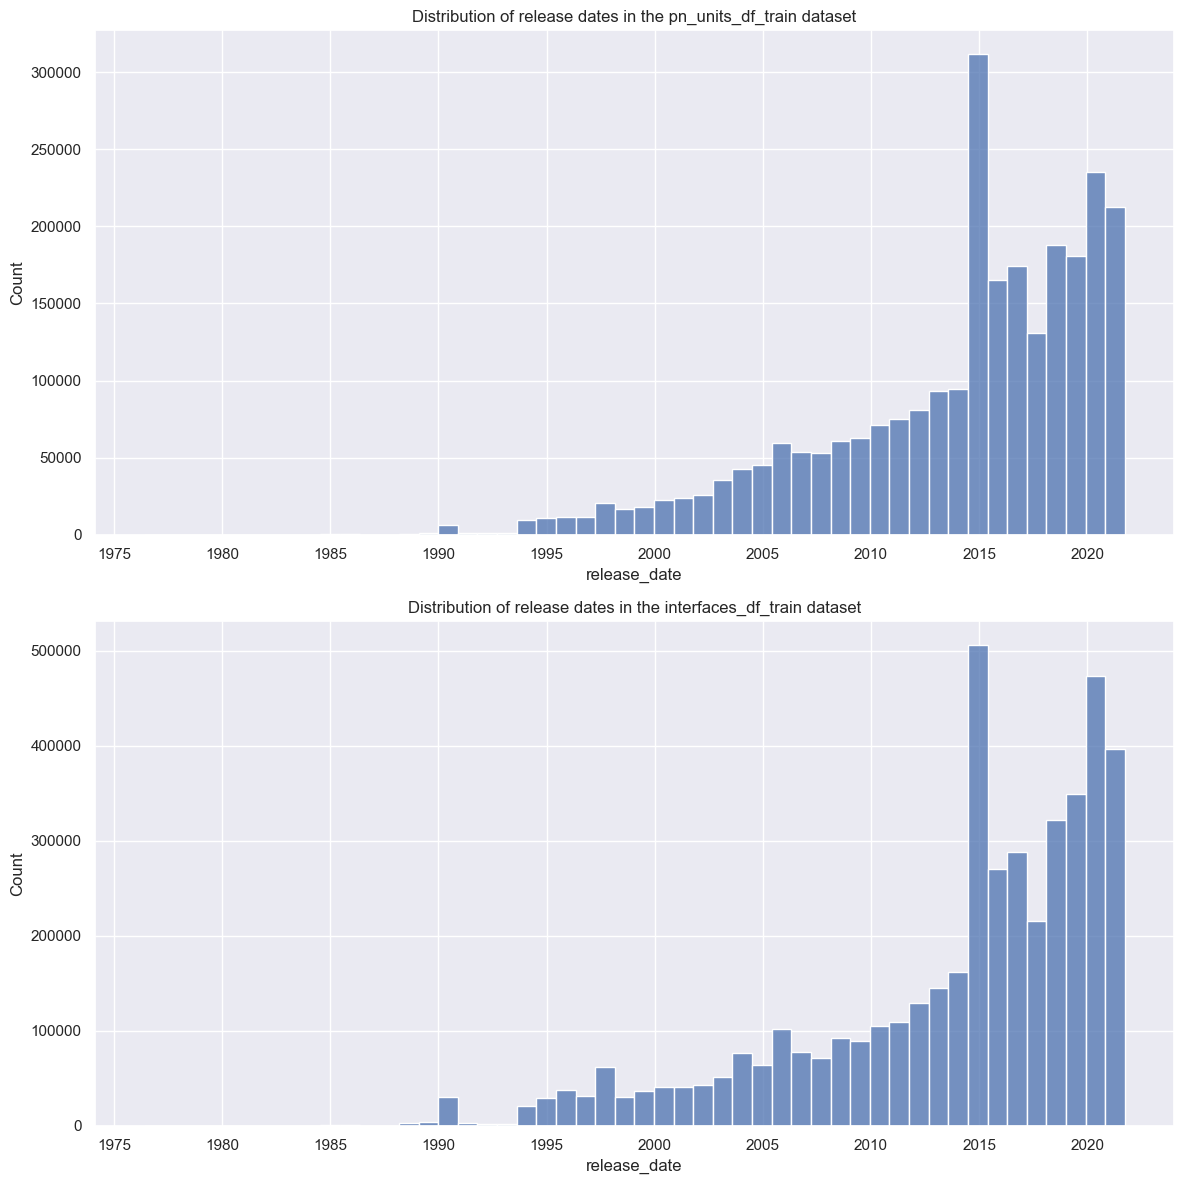

In [3]:
# ...visualize the distribution of release dates in the training data
import matplotlib.pyplot as plt
import seaborn as sns

# Set the theme for seaborn
sns.set_theme()

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Plot the distribution of release dates in the pn_units_df_train dataset
sns.histplot(pn_units_df_train["release_date"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of release dates in the pn_units_df_train dataset")

# Plot the distribution of release dates in the interfaces_df_train dataset
sns.histplot(interfaces_df_train["release_date"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of release dates in the interfaces_df_train dataset")

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

Now, we're done with the training datasets! Onto validation.

 ### Step 2: Filter the validation dataset based on basic criteria

> "Take all targets released after 2021-09-30 and before 2023-01-13 and remove targets with total number of tokens greater than 2560, more than one thousand chains, or resolution greater than 4.5" - AF3 Supplement, p. 31

In [4]:
MIN_VAL_DATE = pd.to_datetime("2021-09-30")
MAX_VAL_DATE = pd.to_datetime("2023-01-13")
TOKEN_LIMIT = 2560
RESOLUTION_LIMIT = 4.5

print(f"Number of rows prior to filtering: {len(pn_units_df_val):,}")

# ...filter to only inclues rows within the PN Units dataframe that are within the validation date range
candidate_pn_units_df = pn_units_df_val[
    (pn_units_df_val["release_date"] > MIN_VAL_DATE) & (pn_units_df_val["release_date"] < MAX_VAL_DATE)
]
print(f"Number of rows within validation date range: {len(candidate_pn_units_df ):,}")

# ...assert that there are no rows with a release date outside of the validation date range
assert candidate_pn_units_df["release_date"].min() > MIN_VAL_DATE
assert candidate_pn_units_df["release_date"].max() < MAX_VAL_DATE

# ...filter again to only include rows with fewer than 2,560 tokens
candidate_pn_units_df = candidate_pn_units_df[candidate_pn_units_df["n_tokens_total"] < TOKEN_LIMIT]
print(f"Number of rows within validation date range and token limit: {len(candidate_pn_units_df ):,}")

# ...assert that there are no rows with more than 2,560 tokens
assert candidate_pn_units_df["n_tokens_total"].max() < TOKEN_LIMIT

# ...filter once more to only include rows with a resolution greater than 4.5 angstrom
candidate_pn_units_df = candidate_pn_units_df[candidate_pn_units_df["resolution"] < RESOLUTION_LIMIT]
print(f"Number of rows within validation date range, token limit, and resolution limit: {len(candidate_pn_units_df):,}")
assert candidate_pn_units_df["resolution"].max() < RESOLUTION_LIMIT

# ...filter to examples with fewer than 1,000 chains
candidate_pn_units_df = candidate_pn_units_df[candidate_pn_units_df["num_polymer_pn_units"] < 1000]
print(
    f"Number of rows within validation date range, token limit, resolution limit, and chain limit: {len(candidate_pn_units_df):,}"
)
assert candidate_pn_units_df["num_polymer_pn_units"].max() < 1000

Number of rows prior to filtering: 868,323
Number of rows within validation date range: 356,861
Number of rows within validation date range and token limit: 106,563
Number of rows within validation date range, token limit, and resolution limit: 104,207
Number of rows within validation date range, token limit, resolution limit, and chain limit: 104,207


Text(0.5, 1.0, 'Distribution of release dates in the pn_units_df_val dataset')

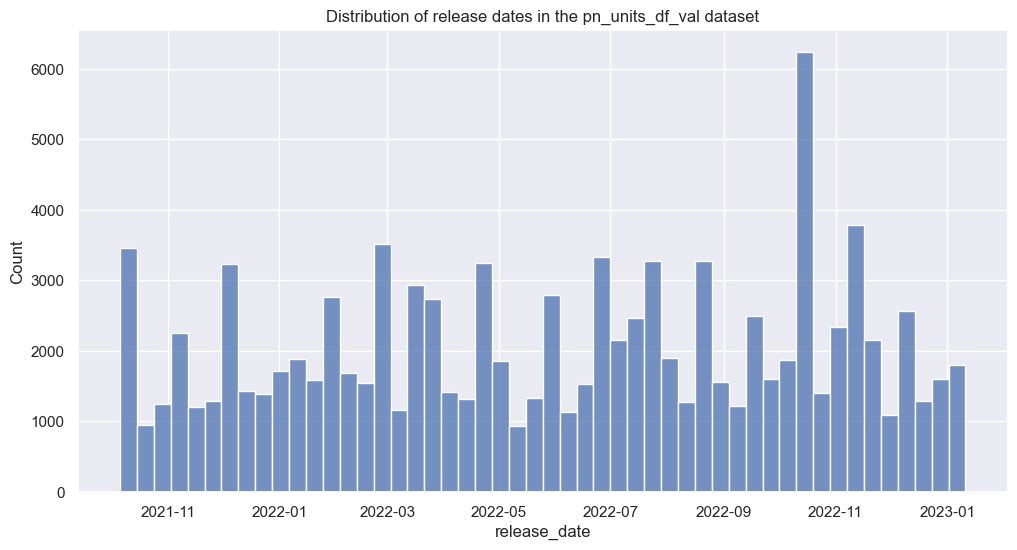

In [5]:
# Create a plot of candidate_pn_units_df by release date
import matplotlib.pyplot as plt
import seaborn

# Set the theme for seaborn
seaborn.set_theme()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the distribution of release dates in the pn_units_df_val dataset
seaborn.histplot(candidate_pn_units_df["release_date"], bins=50, ax=ax)

# Set the title and labels
ax.set_title("Distribution of release dates in the pn_units_df_val dataset")

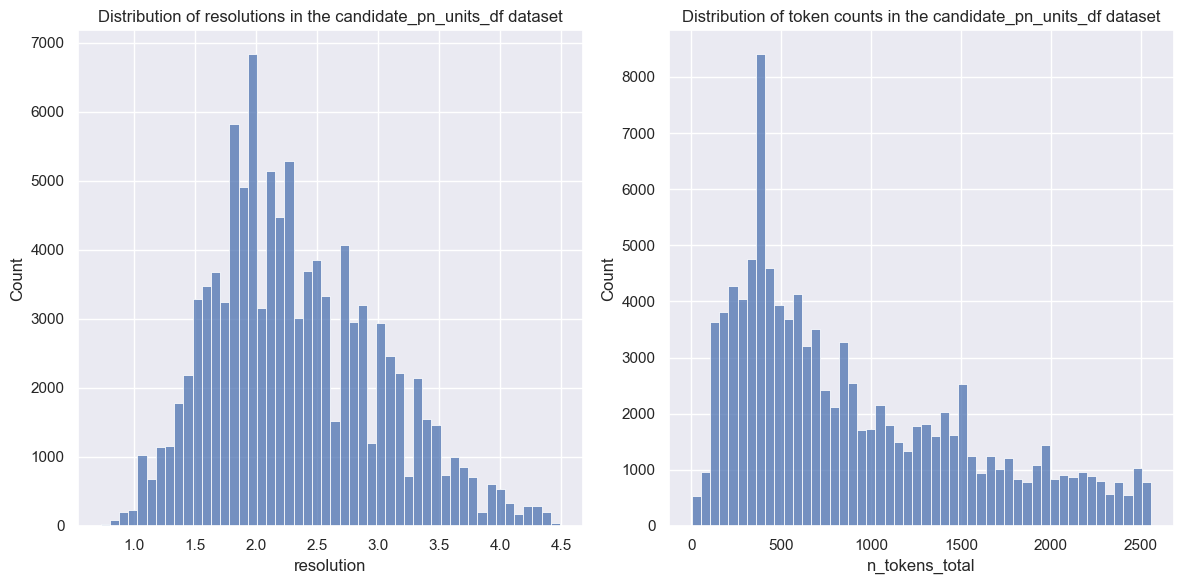

In [6]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the distribution of resolutions in the candidate_pn_units_df dataset
sns.histplot(candidate_pn_units_df["resolution"], bins=50, ax=axes[0])

# Set the title and labels
axes[0].set_title("Distribution of resolutions in the candidate_pn_units_df dataset")

# Plot the distribution of token counts in the candidate_pn_units_df dataset
sns.histplot(candidate_pn_units_df["n_tokens_total"], bins=50, ax=axes[1])

# Set the title and labels
axes[1].set_title("Distribution of token counts in the candidate_pn_units_df dataset")

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

In [7]:
# Filter the pn_units_df_val and the interfaces_df_val to only the PDB IDs present in the candidate_pn_units_df
allowed_pdb_ids = candidate_pn_units_df["pdb_id"].unique()
pn_units_df_val_filtered = pn_units_df_val[pn_units_df_val["pdb_id"].isin(allowed_pdb_ids)]
interfaces_df_val_filtered = interfaces_df_val[interfaces_df_val["pdb_id"].isin(allowed_pdb_ids)]
print(f"Number of rows in the pn_units_df_val_filtered dataset: {len(pn_units_df_val_filtered):,}")
print(f"Number of rows in the interfaces_df_val_filtered dataset: {len(interfaces_df_val_filtered):,}")

Number of rows in the pn_units_df_val_filtered dataset: 132,713
Number of rows in the interfaces_df_val_filtered dataset: 221,368


### Step 3: Filter to low homology interfaces

> Filter to only low homology interfaces, which are defined as those where no target in the training set contains
two chains with high homology to the chains involved in the interface, where high homology here means >
40% sequence identity for polymers or > 0.85 tanimoto similarity for ligands. Additionally filter out interfaces
involving a ligand with ranking model fit less than 0.5 or with multiple residues - AF3 Supplement, p. 31

First, we perform a quick filter based on our existing `cluster` field, since for darn sure we don't want examples with interface clusters seen during training in the validation dataset

In [8]:
import numpy as np

print(f"Starting number of rows in the candidate_val_interfaces dataset: {len(interfaces_df_val_filtered):,}")
# ...filter the validation interfaces to exclude examples without clusters
# (The protein clusters are assigned based on 40% sequence identity; the ligand clusters are assigned based on CCD identity)
candidate_val_interfaces = interfaces_df_val_filtered[
    (interfaces_df_val_filtered["pn_unit_1_cluster"].notnull())
    & (interfaces_df_val_filtered["pn_unit_2_cluster"].notnull() & (interfaces_df_val_filtered["cluster"].notnull()))
]
print(f"Number of rows in the candidate_val_interfaces dataset: {len(candidate_val_interfaces):,}")
assert candidate_val_interfaces["pn_unit_1_cluster"].notnull().all()
assert candidate_val_interfaces["pn_unit_2_cluster"].notnull().all()
assert candidate_val_interfaces["cluster"].notnull().all()

# ...filter the validation interfaces to only include those that are NOT in the training dataset
train_interface_clusters = interfaces_df_train["cluster"].dropna().unique()
candidate_val_interfaces = candidate_val_interfaces[~candidate_val_interfaces["cluster"].isin(train_interface_clusters)]
print(
    f"Number of rows in the candidate_val_interfaces dataset after filtering out training examples clusters: {len(candidate_val_interfaces):,}"
)

# (Sanity check: Ensure that there are no interface clusters in the validation dataset that are also in the training dataset)
candidate_val_interface_clusters = candidate_val_interfaces["cluster"].unique()
common_clusters = np.intersect1d(candidate_val_interface_clusters, train_interface_clusters)
assert len(common_clusters) == 0

Starting number of rows in the candidate_val_interfaces dataset: 221,368
Number of rows in the candidate_val_interfaces dataset: 218,377
Number of rows in the candidate_val_interfaces dataset after filtering out training examples clusters: 75,924


Next, we filter out interfaces involving a ligand with multiple residues or multiple chains, since they're nasty to work with...

In [9]:
from cifutils.enums import ChainType

# ...remove examples where `pn_unit_1` is a non-polymer but is multi-residue
candidate_val_interfaces = candidate_val_interfaces[
    ~(
        (candidate_val_interfaces["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (candidate_val_interfaces["pn_unit_1_is_multiresidue"] | candidate_val_interfaces["pn_unit_1_is_multichain"])
    )
]

# ...and the same for `pn_unit_2`
candidate_val_interfaces = candidate_val_interfaces[
    ~(
        (candidate_val_interfaces["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
        & (candidate_val_interfaces["pn_unit_2_is_multiresidue"] | candidate_val_interfaces["pn_unit_2_is_multichain"])
    )
]
print(
    f"Number of rows in the candidate_val_interfaces dataset after filtering out non-polymer multi-residue chains: {len(candidate_val_interfaces):,}"
)

assert not candidate_val_interfaces["pn_unit_1_is_multichain"].any()
assert not candidate_val_interfaces["pn_unit_2_is_multichain"].any()

# (If `pn_unit_1_is_multiresidue` is True, then `pn_unit_1_non_polymer_res_names` should be None)
assert (
    not candidate_val_interfaces[candidate_val_interfaces["pn_unit_1_is_multiresidue"]][
        "pn_unit_1_non_polymer_res_names"
    ]
    .notnull()
    .any()
)
assert (
    not candidate_val_interfaces[candidate_val_interfaces["pn_unit_2_is_multiresidue"]][
        "pn_unit_2_non_polymer_res_names"
    ]
    .notnull()
    .any()
)

Number of rows in the candidate_val_interfaces dataset after filtering out non-polymer multi-residue chains: 73,929


We can also throw out interfaces that involve a ligand with ranking model fit less than 0.5 (which is, by definition, half of the ligands annotated with fit-to-density)

In [11]:
# ...get the PDB IDs that are still present in the candidate_val_interfaces, and use those to filter the pn_units_df_val_filtered
candidate_val_pdb_ids = candidate_val_interfaces["pdb_id"].unique()
candidate_pn_units = pn_units_df_val_filtered[pn_units_df_val_filtered["pdb_id"].isin(candidate_val_pdb_ids)]

In [15]:
FIT_TO_DENSITY_CUTOFF = 0.5

# ...subset to only non-polymers
candidate_pn_units_non_polmers = candidate_pn_units[candidate_pn_units["q_pn_unit_type"] == ChainType.NON_POLYMER.value]
print(f"Number of non-polymer rows in the candidate_pn_units dataset: {len(candidate_pn_units_non_polmers):,}")

ligands_that_fail_criteria = set()

# ...loop through the non-polymers and note the pn_units that meet the fit-to-density criteria
for row in candidate_pn_units_non_polmers.itertuples():
    # ...eval the "q_pn_unit_ligand_validity" column
    try:
        ligand_validity = eval(row.q_pn_unit_ligand_validity)
    except Exception as e:
        print(f"Error evaluating ligand validity for {row.pdb_id} {row.q_pn_unit_chain_id}: {e}")
        ligand_validity = None

    ranking_model_fit = (
        next(iter(ligand_validity["ranking_model_fit"].values()))
        if ligand_validity and "ranking_model_fit" in ligand_validity
        else None
    )

    # ...if the ranking model fit is below the cutoff, add the information to the set
    if not ranking_model_fit or ranking_model_fit < FIT_TO_DENSITY_CUTOFF:
        ligands_that_fail_criteria.add(tuple([row.pdb_id, row.q_pn_unit_chain_id]))

Number of non-polymer rows in the candidate_pn_units dataset: 49,355
Error evaluating ligand validity for 7smp E: name 'nan' is not defined
Error evaluating ligand validity for 7smp G: name 'nan' is not defined
Error evaluating ligand validity for 7plw F: name 'nan' is not defined
Error evaluating ligand validity for 7p7p BA: name 'nan' is not defined


StopIteration: 

For protein-ligand and ligand-ligand interfaces, we must now perform a thoughtful homology check including tanimoto similarities

In [10]:
from scripts.preprocessing.clustering.build_residue_by_residue_tanimoto_similarity_map import (
    build_residue_by_residue_tanimo_similarity_map_from_pn_units_dfs,
)
import pickle


# ...load the RDKit object lookup table
residue_to_rdkit_mol_map_path = "/projects/msa/temp_while_projects_ml_down/residue_to_rdkit_mol_map.pkl"
with open(residue_to_rdkit_mol_map_path, "rb") as f:
    residue_to_rdkit_mol_map = pickle.load(f)

# ...build the residue-by-residue Tanimoto similarity map
# residue_similarity_map = build_residue_by_residue_tanimo_similarity_map_from_pn_units_dfs(
#     candidate_pn_units,
#     pn_units_df_train,
#     residue_to_rdkit_mol_map,
# )

# ...iterate through all interfaces involving ligands.
# We keep the interface if EITHER:
# - The protein is a member of an unseen cluster; or,
# - The ligand does not closely resemble any ligand in the training set
# (We will use the residue_similarity_map to determine the similarity of the ligand to any ligands in the training set)
# NOTE: Certainly, data leakage may occur given the "OR" (vs. "AND") condition, but this is a reasonable compromise given the data constraints